In [2]:
from sklearn.datasets import load_iris
from sklearn.ensemble import BaggingClassifier

import numpy as np
import pandas as pd

In [15]:
iris = load_iris()
X = iris.data
y = iris.target

In [28]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [29]:
df = pd.DataFrame({'SepalLengthCm':X[:,0], 'SepalWidthCm':X[:,1], 'PetalLengthCm':X[:,2], 'PetalWidthCm':X[:,3], 'Species':y})

In [30]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [31]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])

In [32]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [33]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [34]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

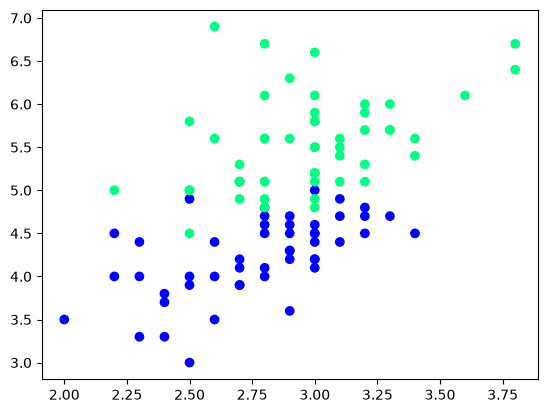

In [41]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'], c=df['Species'],cmap='winter')

In [42]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
61,3.0,4.2,1
57,2.4,3.3,1
52,3.1,4.9,1
64,2.9,3.6,1
87,2.3,4.4,1
105,3.0,6.6,2
80,2.4,3.8,1
77,3.0,5.0,1
93,2.3,3.3,1


In [43]:
# Taking only 10 rowa for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [45]:
df_train

,SepalWidthCm,PetalLengthCm,Species
52,3.1,4.9,1
103,2.9,5.6,2
106,2.5,4.5,2
91,3.0,4.6,1
133,2.8,5.1,2
73,2.8,4.7,1
123,2.7,4.9,2
57,2.4,3.3,1
108,2.5,5.8,2
69,2.5,3.9,1


In [46]:
df_val

,SepalWidthCm,PetalLengthCm,Species
136,3.4,5.6,2
55,2.8,4.5,1
118,2.6,6.9,2
82,2.7,3.9,1
126,2.8,4.8,2


In [47]:
df_test

,SepalWidthCm,PetalLengthCm,Species
146,2.5,5.0,2
129,3.0,5.8,2
87,2.3,4.4,1
93,2.3,3.3,1
107,2.9,6.3,2


In [48]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [49]:
y_test

array([2, 1, 2, 1, 2])

## Case 1- Bagging

In [50]:
# DAta for tree 1
df_bag = df_train.sample(8,replace=True)

X= df_bag.iloc[:,0:2]
y= df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
73,2.8,4.7,1
52,3.1,4.9,1
73,2.8,4.7,1
123,2.7,4.9,2
133,2.8,5.1,2
69,2.5,3.9,1
108,2.5,5.8,2


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [60]:
dt_bag1 = DecisionTreeClassifier(max_depth=1)
dt_bag1.fit(X,y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.5, 0.75, 'x[1] <= 4.8\ngini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.625, 0.5, '  False')]

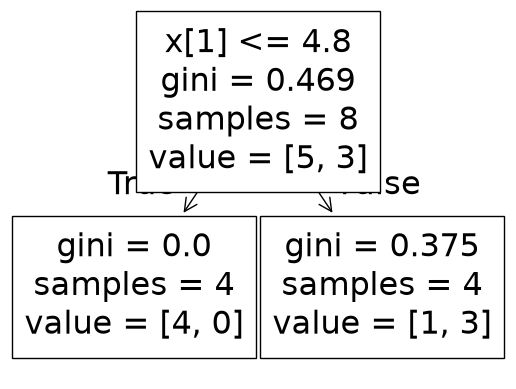

In [61]:
plot_tree(dt_bag1)

In [64]:
# DAta for tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
123,2.7,4.9,2
52,3.1,4.9,1
103,2.9,5.6,2
69,2.5,3.9,1
108,2.5,5.8,2
133,2.8,5.1,2
52,3.1,4.9,1


In [65]:
dt_bag2 = DecisionTreeClassifier()
plot_tree(dt_bag2,X,y)

TypeError: too many positional arguments